In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd

import pickle

import scanpy as sc
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.metrics import rand_score, confusion_matrix

from openTSNE import TSNE
from phate import PHATE
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from umap import UMAP

import sys
sys.path.append('../code')
from align import *
from embed import *
from eval import *

import time

# Load data

In [12]:
with open('../../rna-seq-tsne/tasic_data.pkl', 'rb') as file:
    tasic = pickle.load(file)

In [13]:
X = tasic['counts']
n = X.shape[0]

In [14]:
labels = tasic['clusters']

In [15]:
colors =  tasic['clusterColors']
cmap = ListedColormap(colors)

## Cluster the data

In [7]:
st = time.time()
adata = sc.AnnData(X)
sc.pp.neighbors(adata, n_neighbors=15)
time.time()-st

36.37763810157776

In [8]:
st = time.time()
sc.tl.leiden(adata, resolution=1.5) 
clusters = adata.obs['leiden']
rand_score(clusters, labels)
time.time()-st

C:\Users\codae\AppData\Local\Temp\ipykernel_32424\2162415529.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.5)


2.1507229804992676

In [9]:
clusters = np.array(clusters).astype(int)
np.unique(clusters, return_counts = True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]),
 array([1480, 1418, 1133, 1037, 1029, 1007,  988,  888,  837,  766,  747,
         730,  713,  697,  668,  644,  615,  583,  522,  498,  477,  456,
         452,  427,  418,  388,  385,  384,  369,  360,  329,  319,  313,
         236,  190,  189,  179,  146,  140,  135,  119,   92,   89,   77,
          77,   76], dtype=int64))

## Embed the clusters

In [10]:
st = time.time()
pca  = PCA(n_components = 2)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    cluster_emb = pca.fit_transform(X[clusters == i])
    embeddings[clusters == i] = cluster_emb 
time.time()-st

0.19632720947265625

## Align

In [11]:
st = time.time()
alignment_idxs = np.random.choice(n, 5000, replace = False)
embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]
X_samples = X[alignment_idxs,:]

#reformat
distances = {} 

n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = cdist(X_samples[clusters_sampled == i,: ], 
                                   X_samples[clusters_sampled == j,: ])
time.time()-st

0.2655353546142578

In [12]:
st = time.time()
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1)
ce_pca_1 = out.align_embedding(m = 50 )
ce_pca_1 =  out.embed_points(embeddings,clusters)
time.time()-st

251.70154237747192

In [15]:
out.get_default_alpha()

4.27554531653007

In [13]:
st = time.time()
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =4.27)
ce_pca_427=out.align_embedding(m = 50 )
ce_pca_427 =  out.embed_points(embeddings,clusters)
time.time()-st

193.52839517593384

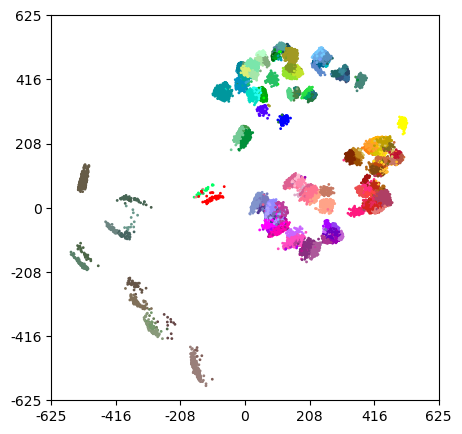

In [9]:
plt.figure(figsize = [5,5])
plt.scatter(ce_pca_427[:,0], ce_pca_427[:,1], c = labels, cmap =cmap, s = 1)

plt.xlim(-775,475)
plt.ylim(-850,400)
plt.xticks(np.linspace(-775,475,7), np.linspace(-625,625,7).astype(int))
plt.yticks(np.linspace(-850,400, 7), np.linspace(-625,625,7).astype(int))
plt.savefig('../figures/mouse_cortex/ce_pca_427.png', format='png', dpi=300, bbox_inches='tight')

In [10]:
ce_pca_1_, _ = procrustes(ce_pca_427, ce_pca_1)

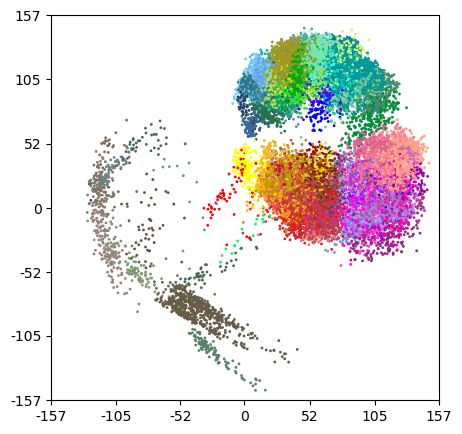

In [12]:
plt.figure(figsize = [5,5])
plt.scatter(ce_pca_1_[:,0], ce_pca_1_[:,1], c = labels, cmap =cmap, s = 1)
plt.xlim(-215,100)
plt.ylim(-215,100)
plt.xticks(np.round(np.linspace(-215,100,7),0),np.linspace(-157.5, 157.5, 7).astype(int))
plt.yticks(np.round(np.linspace(-215,100,7),0),np.linspace(-157.5, 157.5, 7).astype(int))
plt.savefig('../figures/mouse_cortex/ce_pca_1.png', format='png', dpi=300, bbox_inches='tight')

In [22]:
# save embeddings and clusters
with open('../results/mouse_cortex/clusters.pkl', 'wb') as file:  
    pickle.dump(clusters, file)

with open('../results/mouse_cortex/ce_pca_embeddings.pkl', 'wb') as file:  
    pickle.dump([ce_pca_1, ce_pca_427], file)

In [14]:
st = time.time()
trimap_embeddings =  np.load("../results/mouse_cortex/trimap_clusters.npy", allow_pickle=False)

# rescale the embeddings:
for i in range(n_clusters):
    orig_pdist = pdist(X[clusters == i])
    emb_pdist = pdist(trimap_embeddings[clusters == i])
    scale  = np.sum(orig_pdist*emb_pdist)/np.sum(emb_pdist**2)
    trimap_embeddings[clusters == i] *= scale
time.time()-st

0.3344247341156006

In [48]:
embedding_sampled = trimap_embeddings[alignment_idxs]

out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1)
out.get_default_alpha()

4.629059627152528

In [15]:
st = time.time()
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =4.63)
ce_trimap = out.align_embedding(m = 50 )
ce_trimap =  out.embed_points(trimap_embeddings,clusters)
time.time()-st

192.02964568138123

In [15]:
ce_trimap_, _ = procrustes(ce_pca_427, ce_trimap)

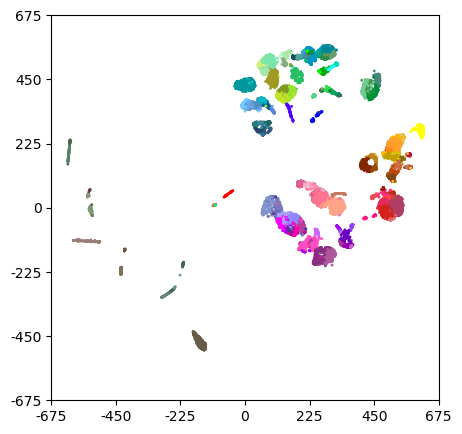

In [16]:
plt.figure(figsize = [5,5])
plt.scatter(ce_trimap_[:,0], ce_trimap_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-900,450)
plt.ylim(-900,450)
plt.xticks(np.linspace(-900,450,7), np.linspace(-675,675,7).astype(int))
plt.yticks(np.linspace(-900,450, 7), np.linspace(-675,675,7).astype(int))
plt.savefig('../figures/mouse_cortex/ce_trimap.png', format='png', dpi=300, bbox_inches='tight')

In [ ]:
with open('../results/mouse_cortex/ce_trimap_embeddings.pkl', 'wb') as file:  
    pickle.dump([ce_trimap], file)

## Other Methods

In [16]:
st = time.time()
tsne30 = TSNE(perplexity = 30, negative_gradient_method="fft").fit(X)
tsne30 = np.array(tsne30)
time.time()-st

133.268141746521

In [17]:
st = time.time()
pca = PCA(n_components = 2).fit_transform(X)
time.time()-st

0.015993833541870117

In [6]:
st = time.time()
umap = UMAP().fit_transform(X)
time.time()-st

C:\Users\codae\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


32.062928915023804

In [19]:
st = time.time()
l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 1000)
isomap =  l_isomap.fit_transform(adata)
time.time()-st

14.795978784561157

In [20]:
st = time.time()
phate = PHATE().fit_transform(X)
time.time()-st

Calculating PHATE...
  Running PHATE on 23822 observations and 50 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 2.71 seconds.
    Calculating affinities...
    Calculated affinities in 1.56 seconds.
  Calculated graph and diffusion operator in 4.30 seconds.
  Calculating landmark operator...
    Calculating SVD...


C:\Users\codae\anaconda3\Lib\site-packages\phate\phate.py:919: RuntimeWarning: Graph is disconnected with 5 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(


    Calculated SVD in 1.56 seconds.
    Calculating KMeans...
    Calculated KMeans in 4.72 seconds.
  Calculated landmark operator in 6.29 seconds.
  Calculating optimal t...
    Automatically selected t = 21
  Calculated optimal t in 2.64 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.71 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.99 seconds.
Calculated PHATE in 20.04 seconds.


20.04874849319458

In [74]:
trimap =  np.load("../results/mouse_cortex/trimap_full.npy", allow_pickle=False)

In [17]:
tsne30_, _  = procrustes(ce_pca_427, tsne30)
pca_, _  = procrustes(ce_pca_427, pca)
isomap_, _  = procrustes(ce_pca_427, isomap)
umap_, _  = procrustes(ce_pca_427, umap)
phate_, _  = procrustes(ce_pca_427, phate)
trimap_, _  = procrustes(ce_pca_427, trimap)

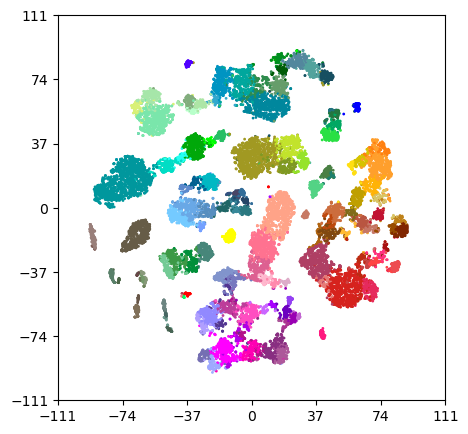

In [13]:
plt.figure(figsize = [5,5])
plt.scatter(tsne30_[:,0], tsne30_[:,1], c = labels, s = 1, cmap = cmap)
plt.xlim(-111,111)
plt.ylim(-111,111)
plt.xticks(np.linspace(-111,111,7))
plt.yticks(np.linspace(-111,111,7))
plt.savefig('../figures/mouse_cortex/tsne.png', format='png', dpi=300, bbox_inches='tight')

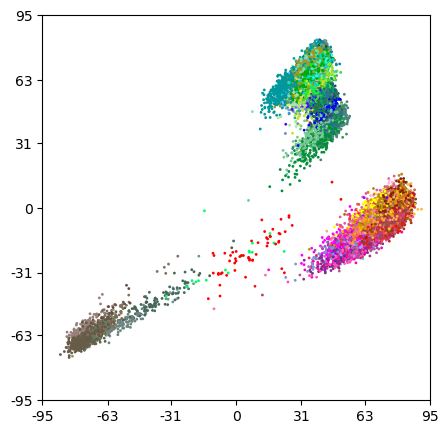

In [19]:
plt.figure(figsize = [5,5])
plt.scatter(pca_[:,0], pca_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-140,50)
plt.ylim(-120,70)
plt.xticks(np.round(np.linspace(-140,50,7),0),  np.linspace(-95,95,7).astype(int))
plt.yticks(np.round(np.linspace(-120,70, 7),0), np.linspace(-95,95,7).astype(int))
plt.savefig('../figures/mouse_cortex/pca.png', format='png', dpi=300, bbox_inches='tight')

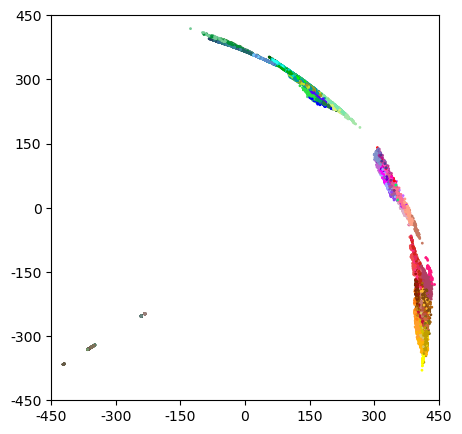

In [21]:
plt.figure(figsize = [5,5])
plt.scatter(isomap_[:,0], isomap_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-650,250)
plt.ylim(-550,350)
plt.xticks(np.round(np.linspace(-650,250,7),0),  np.linspace(-450,450,7).astype(int))
plt.yticks(np.round(np.linspace(-550,350, 7),0), np.linspace(-450,450,7).astype(int))
plt.savefig('../figures/mouse_cortex/isomap.png', format='png', dpi=300, bbox_inches='tight')

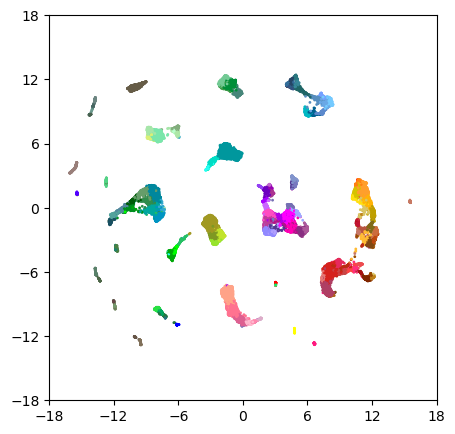

In [16]:
plt.figure(figsize = [5,5])
plt.scatter(umap_[:,0], umap_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-18,18)
plt.ylim(-18,18)
plt.xticks(np.linspace(-18,18,7))
plt.yticks(np.linspace(-18,18,7))
plt.savefig('../figures/mouse_cortex/umap.png', format='png', dpi=300, bbox_inches='tight')

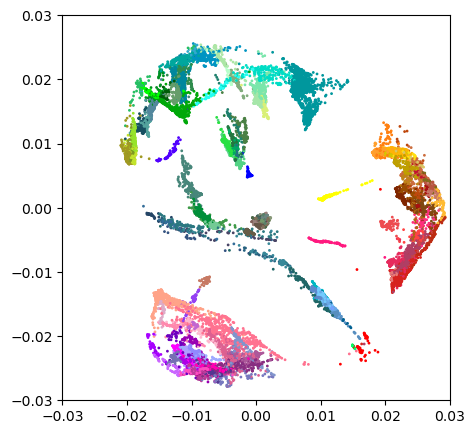

In [17]:
plt.figure(figsize = [5,5])
plt.scatter(phate_[:,0], phate_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-.03,.03)
plt.ylim(-.03,.03)
plt.xticks(np.linspace(-.03,.03,7))
plt.yticks(np.linspace(-.03,.03,7))

plt.savefig('../figures/mouse_cortex/phate.png', format='png', dpi=300, bbox_inches='tight')

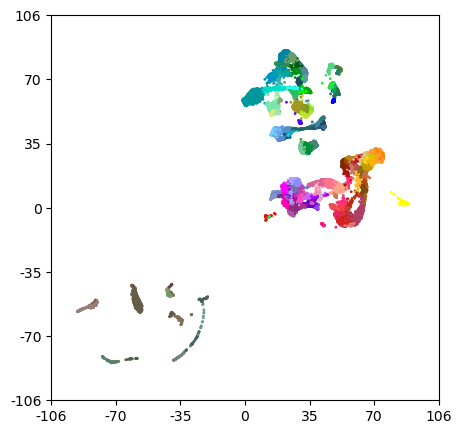

In [23]:
plt.figure(figsize = [5,5])
plt.scatter(trimap_[:,0], trimap_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-135,75)
plt.xlim(-135,75)
plt.xticks(np.round(np.linspace(-135,75,7),0), np.linspace(-106,106,7).astype(int))
plt.yticks(np.round(np.linspace(-135,75, 7),0), np.linspace(-106,106,7).astype(int))
plt.savefig('../figures/mouse_cortex/trimap.png', format='png', dpi=300, bbox_inches='tight')

In [102]:
all_embs = [ce_pca_1, ce_pca_427, ce_trimap, tsne30, pca, isomap, umap, phate, trimap]
with open('../results/mouse_cortex/embeddings.pkl', 'wb') as file:  
    pickle.dump(all_embs, file)

# Evaluation

In [6]:
with open('../results/mouse_cortex/embeddings.pkl', 'rb') as file:  
    all_embs = pickle.load( file)
ce_pca_1, ce_pca_427, ce_trimap, tsne30, pca, isomap, umap, phate, trimap = all_embs

In [28]:
idxs = np.random.choice(n, 5000, replace = False)

orig_distances = squareform(pdist(X[idxs]))

In [27]:
len(np.unique(labels[idxs])), len(np.unique(labels)) #make sure all clusters are represented 

(133, 133)

In [29]:
for emb in all_embs:
    emb_distances =  squareform(pdist(emb[idxs]))
    spearman_scores = spearman(orig_distances, emb_distances, labels[idxs])
    stress_scores = normalized_stress(orig_distances, emb_distances, labels[idxs])
    class_score = class_preservation(orig_distances, emb_distances, labels[idxs])
    scaled_stress_scores =  scale_normalized_stress(orig_distances, emb_distances, labels[idxs])
    recall_score = knn_recall(X[idxs], emb[idxs], [30])
    
    formatted = " & ".join(
    [
        f"${spearman_scores[0]:.2f}$",
        f"${stress_scores[0]:.2f}$",
        f"${scaled_stress_scores[0]:.2f}$",
        f"${recall_score[0]:.2f}$",
        *[f"${x:.2f}$" for x in spearman_scores[1:]],
        *[f"${x:.2f}$" for x in stress_scores[1:]],
        *[f"${x:.2f}$" for x in scaled_stress_scores[1:]],
        f"${class_score:.2f}$"
    ]
)


    print(formatted)
    print()
    

$0.68$ & $0.50$ & $0.35$ & $0.22$ & $0.35$ & $0.88$ & $0.28$ & $0.27$ & $0.16$ & $0.27$ & $0.83$

$0.68$ & $0.63$ & $0.43$ & $0.56$ & $0.36$ & $0.91$ & $2.62$ & $3.16$ & $0.08$ & $0.26$ & $0.86$

$0.65$ & $0.71$ & $0.49$ & $0.58$ & $0.24$ & $0.90$ & $2.90$ & $3.53$ & $0.08$ & $0.26$ & $0.84$

$0.68$ & $0.84$ & $0.42$ & $0.60$ & $0.02$ & $0.55$ & $0.35$ & $0.41$ & $0.09$ & $0.40$ & $0.59$

$0.58$ & $0.73$ & $0.41$ & $0.11$ & $0.60$ & $0.91$ & $0.47$ & $0.43$ & $0.18$ & $0.37$ & $0.94$

$0.37$ & $0.63$ & $0.52$ & $0.24$ & $0.08$ & $0.80$ & $2.53$ & $3.14$ & $0.12$ & $0.39$ & $0.73$

$0.57$ & $0.98$ & $0.51$ & $0.58$ & $0.02$ & $0.49$ & $0.87$ & $0.88$ & $0.08$ & $0.40$ & $0.43$

$0.46$ & $1.00$ & $0.50$ & $0.36$ & $0.05$ & $0.39$ & $1.00$ & $1.00$ & $0.10$ & $0.48$ & $0.28$

$0.58$ & $0.92$ & $0.44$ & $0.54$ & $0.25$ & $0.87$ & $0.53$ & $0.48$ & $0.07$ & $0.32$ & $0.86$



In [30]:
recall_results = []

for emb in all_embs:
    recall_score = knn_recall(X[idxs,:], emb[idxs,:], np.arange(5,250,5))
    recall_results += [recall_score]


In [7]:

with open('../results/mouse_cortex/knn.pkl', 'rb') as file:  
    recall_results  = pickle.load(file)

In [8]:

colors = ['#3182bd', '#aec7e8', '#17becf', '#ff7f0e', '#d62728', '#31a354', '#8c564b','#9467bd',  '#e377c2']
emb_labels  = [r'C+E (PCA, $\alpha = 1$)', r'C+E (PCA, $\alpha = 1.1$)', 'C+E (TriMap)', 't-SNE',
          'PCA', 'L-Isomap', 'UMAP', 'PHATE', 'TriMap']

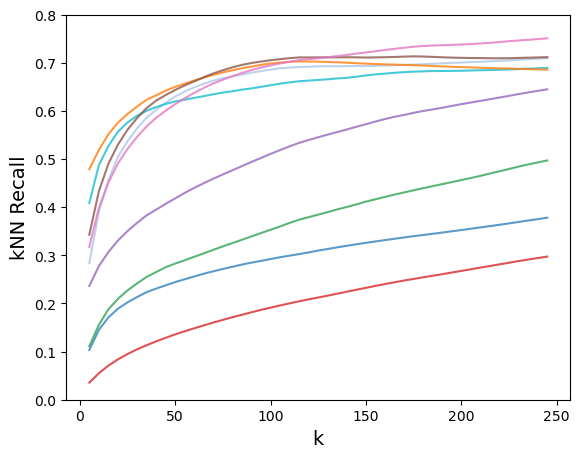

In [9]:
plt.figure(figsize = [6.5,5])
emb_labels  = [r'C+E ($\alpha = 1$)', r'C+E ($\alpha = 1.1$)', 'C+E trimap', 't-SNE (u = 30)',
          'PCA', 'L-Isomap', 'UMAP', 'PHATE', 'TriMap']
for i,r in enumerate(recall_results):
    plt.plot(np.arange(5,250,5), r, label = emb_labels[i], color = colors[i], alpha = .8)
# plt.legend()
plt.xlabel('k', fontsize = 14)
plt.ylabel('kNN Recall', fontsize = 14)

plt.ylim(0,.8)

plt.savefig('../figures/mouse_cortex/knn.png', format='png', dpi=300, bbox_inches='tight')

In [10]:

with open('../results/mouse_cortex/knn.pkl', 'wb') as file:  
    pickle.dump(recall_results, file)